# EDA Summary
**KEY FINDINGS AT A GLANCE**

---

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

TARGET = 'IsBadBuy'
DATA_PATH_INTERIM = '../data/02_interim/'

df_eda = pd.read_parquet(f'{DATA_PATH_INTERIM}df_eda.parquet')
df_impute = pd.read_parquet(f'{DATA_PATH_INTERIM}df_impute.parquet')
df_clean = pd.read_parquet(f'{DATA_PATH_INTERIM}df_clean.parquet')

print(f"df_eda    {df_eda.shape} geladen")
print(f"df_impute {df_impute.shape} geladen")
print(f"df_clean  {df_clean.shape} geladen")

df_eda    (52496, 33) geladen
df_impute (52496, 32) geladen
df_clean  (52350, 35) geladen


## Findings im Bild

#### Data Completeness

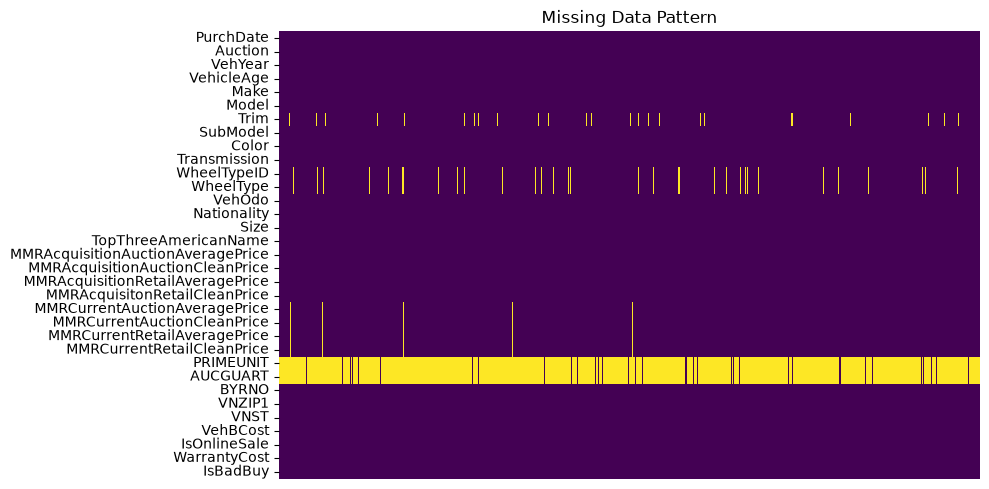

In [2]:
plt.figure(figsize=(10, 5))
sns.heatmap(df_eda.isnull().T, cbar=False, cmap='viridis', xticklabels=False, yticklabels=True)
plt.title('Missing Data Pattern')
plt.tight_layout()
plt.show()

#### Data Integrity

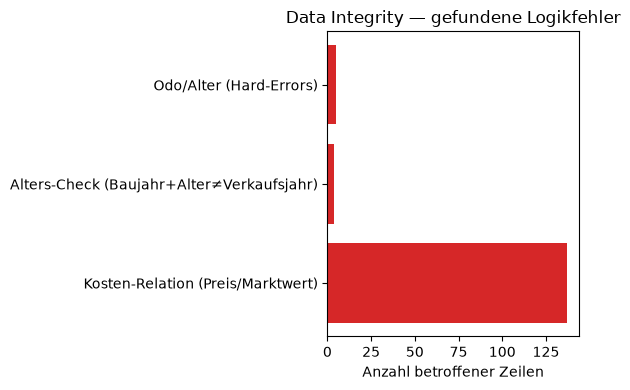

In [3]:
integrity_counts = {
    'Kosten-Relation (Preis/Marktwert)': 137,
    'Alters-Check (Baujahr+Alter≠Verkaufsjahr)': 4,
    'Odo/Alter (Hard-Errors)': 5,
}
plt.figure(figsize=(6, 4))
plt.barh(list(integrity_counts.keys()), list(integrity_counts.values()), color='#d62728')
plt.xlabel('Anzahl betroffener Zeilen')
plt.title('Data Integrity — gefundene Logikfehler')
plt.tight_layout()
plt.show()

#### Distribution & Outliers

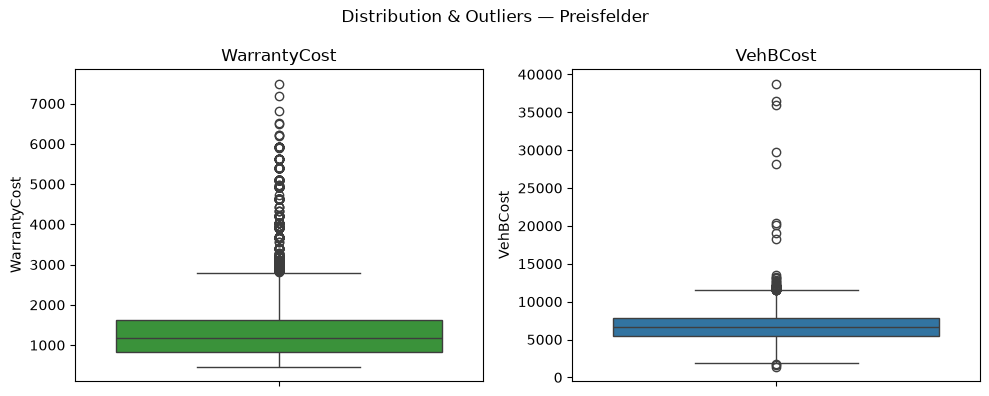

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=df_impute['WarrantyCost'], ax=axes[0], color='#2ca02c')
axes[0].set_title('WarrantyCost')
sns.boxplot(y=df_impute['VehBCost'], ax=axes[1], color='#1f77b4')
axes[1].set_title('VehBCost')
plt.suptitle('Distribution & Outliers — Preisfelder')
plt.tight_layout()
plt.show()

#### Relationships / Multikollinearität

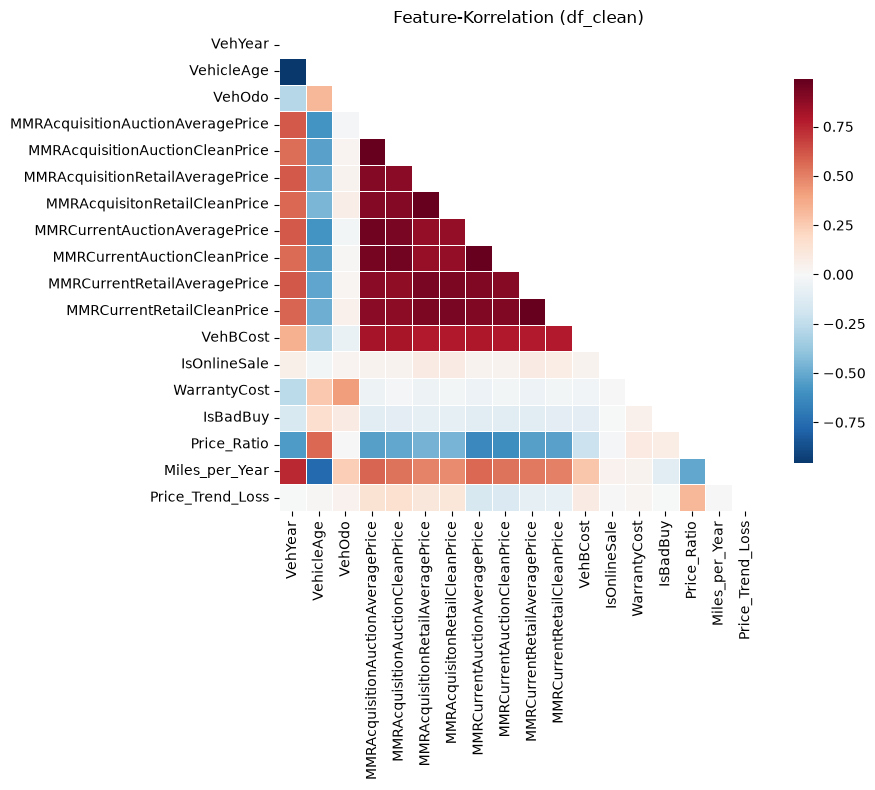

In [5]:
num_cols = df_clean.select_dtypes(include=[np.number]).columns
corr_matrix = df_clean[num_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0, square=True,
            linewidths=.5, cbar_kws={'shrink': .8})
plt.title('Feature-Korrelation (df_clean)')
plt.tight_layout()
plt.show()

#### Target & Imbalance

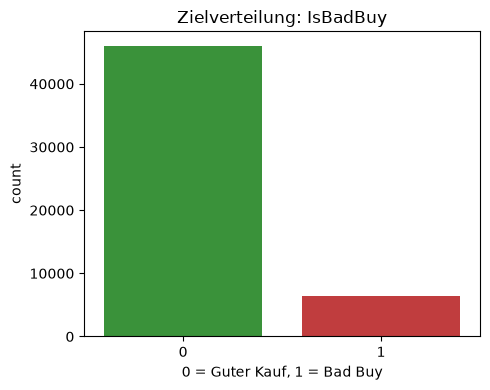

In [6]:
plt.figure(figsize=(5, 4))
sns.countplot(x=TARGET, data=df_eda, hue=TARGET, palette=['#2ca02c', '#d62728'], legend=False)
plt.title('Zielverteilung: IsBadBuy')
plt.xlabel('0 = Guter Kauf, 1 = Bad Buy')
plt.tight_layout()
plt.show()

#### Feature Struktur

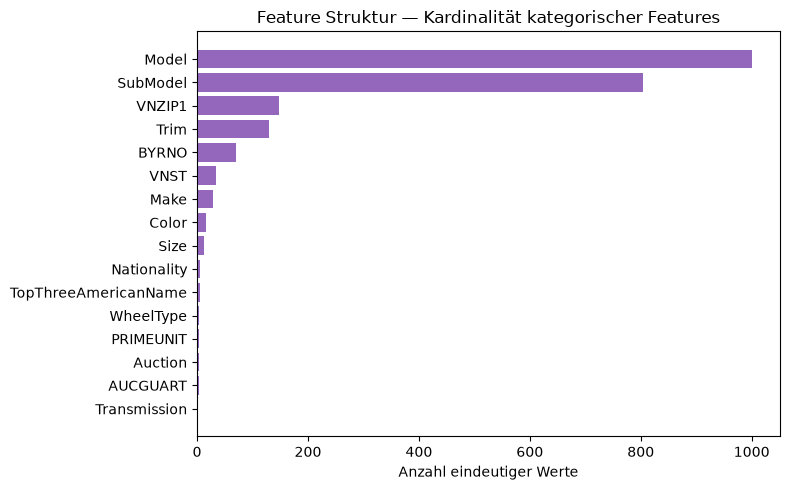

In [7]:
cat_cols = df_impute.select_dtypes(include=['object', 'category']).columns
cardinality = df_impute[cat_cols].nunique().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(cardinality.index[::-1], cardinality.values[::-1], color='#9467bd')
plt.xlabel('Anzahl eindeutiger Werte')
plt.title('Feature Struktur — Kardinalität kategorischer Features')
plt.tight_layout()
plt.show()

#### Erste Signal-Hinweise

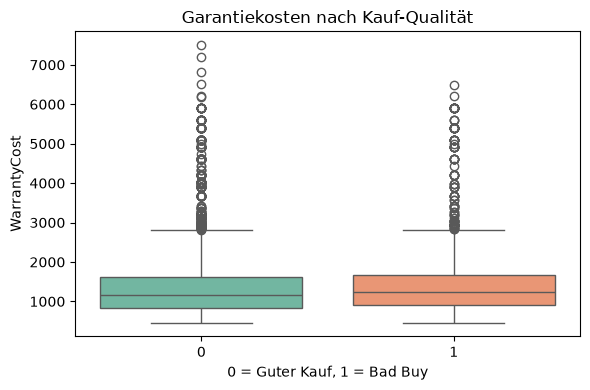

In [8]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_impute, x=TARGET, y='WarrantyCost', palette='Set2', hue=TARGET, legend=False)
plt.title('Garantiekosten nach Kauf-Qualität')
plt.xlabel('0 = Guter Kauf, 1 = Bad Buy')
plt.tight_layout()
plt.show()

## Findings im Überblick

| Thema | Befund | Konsequenz |
|:---|:---|:---|
| **Data Completeness** | Datensatz grundsätzlich sauber (keine Duplikate). `PRIMEUNIT`/`AUCGUART` praktisch unbrauchbar (~95 % NaN). Restliche Missing Values gering. 0-Werte in Preisfeldern sind versteckte Missing Values. | Datenqualität reicht für Modeling — Preisfeatures müssen aber korrekt rekonstruiert werden. |
| **Data Integrity** | Keine offensichtlichen Logikfehler. `VehYear` + `VehicleAge` redundant. Preislogik konsistent (Clean > Average etc.). | Redundante Features → Risiko für Multikollinearität. |
| **Distribution & Outliers** | Starke rechtsschiefe Verteilungen bei Preisfeatures. Signifikante, aber realistische Outlier (teure Autos, keine Fehler). | Nicht entfernen — transformieren (Log-Transform / Clipping). |
| **Relationships / Multikollinearität** | Massive Korrelationen (alle MMR-Features, `VehYear` vs. `VehicleAge`). Viele Features enthalten dieselbe Information. | Feature Reduction ist zwingend notwendig. |
| **Target & Imbalance** | 12,35 % BadBuys — stark unausgewogen, klassischer Accuracy-Fail. | Recall ist die kritische Metrik — schlechte Autos vermeiden. |
| **Feature Struktur** | Viele High-Cardinality-Features (`Model`, `SubModel`, `BYRNO`, `VNZIP1`). Kategorische Features dominieren. | Encoding ist zentraler Erfolgsfaktor. |
| **Erste Signal-Hinweise** | `WarrantyCost` zeigt Unterschiede zwischen den Klassen. Preisrelationen sind wahrscheinlich der stärkste Prädiktor. | Hypothese: "Zu günstig gekauft" ist ein Risikoindikator. |